***

### **Unsupervised Anomaly Detection on the Elliptic Bitcoin Transaction Graph: A Multi-Method Comparison**

***

**notebook 01:** data exploration & preparation (elliptic bitcoin, UML)

**project root:** parent of the `notebooks/` folder (`elliptic_bitcoin_project/`).

**this notebook:**
- load raw CSVs, check schema, merge tables
- quick EDA and **time-based** train / val / test splits
- build **node index** and **`edge_index`** for graph code in notebook 02
- save **`artifacts/prep_bundle.pkl`**

***

### 1] overview: notebook split

| notebook | role |
|----------|------|
| **01 (this)** | EDA, splits, graph indexing → save `artifacts/prep_bundle.pkl` |
| **02** | load bundle, unsupervised models (e.g. isolation forest, graph AE), **AUROC / AUPRC** on val & test (labeled rows only) |

**authentic UML (reminder)**
- do **not** use fraud labels inside any **training loss** in 02
- optional **policy P1:** when fitting on the train time window, you may **drop** known-illicit rows from `fit()` — still no supervised target in the loss
- labels are for **evaluation** (and optional threshold tuning on **val**, not test)

### 2] paths, imports, folders

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# parent of notebooks/ = project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "elliptic_bitcoin_dataset"
ARTIFACTS = PROJECT_ROOT / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# neat default plot style (matplotlib only — no extra deps)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fafafa",
        "axes.grid": True,
        "grid.alpha": 0.35,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)

print("project root:", PROJECT_ROOT.resolve())
print("data dir exists:", DATA_DIR.is_dir())
print("artifacts:", ARTIFACTS.resolve())

project root: F:\msc ds\semester 2\UML\uml project\elliptic_bitcoin_project
data dir exists: True
artifacts: F:\msc ds\semester 2\UML\uml project\elliptic_bitcoin_project\artifacts


### 3] load raw tables

elliptic ships **features** (no header), **classes** (`txId`, `class`), **edgelist** (`txId1` → `txId2`).

columns: `txId`, `time_step`, then **165** numeric features `f_0` … `f_164` (**167** columns total).

In [2]:
classes = pd.read_csv(DATA_DIR / "elliptic_txs_classes.csv")
edges = pd.read_csv(DATA_DIR / "elliptic_txs_edgelist.csv")
feat_cols = ["txId", "time_step"] + [f"f_{i}" for i in range(165)]
features = pd.read_csv(
    DATA_DIR / "elliptic_txs_features.csv",
    header=None,
    names=feat_cols,
)

print("classes:", classes.shape, list(classes.columns))
print("edges:  ", edges.shape, list(edges.columns))
print("features:", features.shape)
print("\nclass value counts:")
print(classes["class"].astype(str).value_counts())

classes: (203769, 2) ['txId', 'class']
edges:   (234355, 2) ['txId1', 'txId2']
features: (203769, 167)

class value counts:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


### 4] sanity checks on shapes and column names

In [3]:
assert features.shape[1] == 167, "expected 167 feature columns"
assert len(features) == len(classes), "features and classes row counts must match"
assert {"txId", "class"}.issubset(classes.columns)
assert {"txId1", "txId2"}.issubset(edges.columns)
print("basic checks passed.")

basic checks passed.


### 5] merge features and labels

one row per transaction: features + `class` for evaluation masks later. inner join on `txId` should keep all rows if data is standard.

In [4]:
df = features.merge(classes, on="txId", how="inner")
assert len(df) == len(features)
df = df.copy()
df["class_str"] = df["class"].astype(str)
# stable row order — all later masks and X rows must match
df = df.sort_values("txId").reset_index(drop=True)
print("merged shape (sorted by txId):", df.shape)
df.head(3)

merged shape (sorted by txId): (203769, 169)


,txId,time_step,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_157,f_158,f_159,f_160,f_161,f_162,f_163,f_164,class,class_str
0,1076,48,-0.168500,0.270909,-0.091383,-0.046932,-0.043875,-0.029140,-0.061584,-0.163591,...,1.461330,1.461369,0.018279,0.470019,1.216796,1.151607,1.519700,1.521399,unknown,unknown
1,2534,6,-0.170834,-0.131425,1.018602,0.028105,0.055376,0.054722,-0.061584,-0.163572,...,0.955101,0.459257,-0.098889,-0.087490,-0.099080,-0.122137,-0.379970,-0.379288,2,2
2,3181,34,1.305212,-0.210553,-1.756361,-0.121970,97.300650,-0.113002,-0.061584,1.348765,...,0.059948,0.113967,-0.098889,1.969527,0.037532,-0.131010,0.006994,0.017772,2,2


### 6] EDA: time steps and class mix

splits use **`time_step`**. confirm illicit appears in val/test; if not, adjust fractions in the next step.

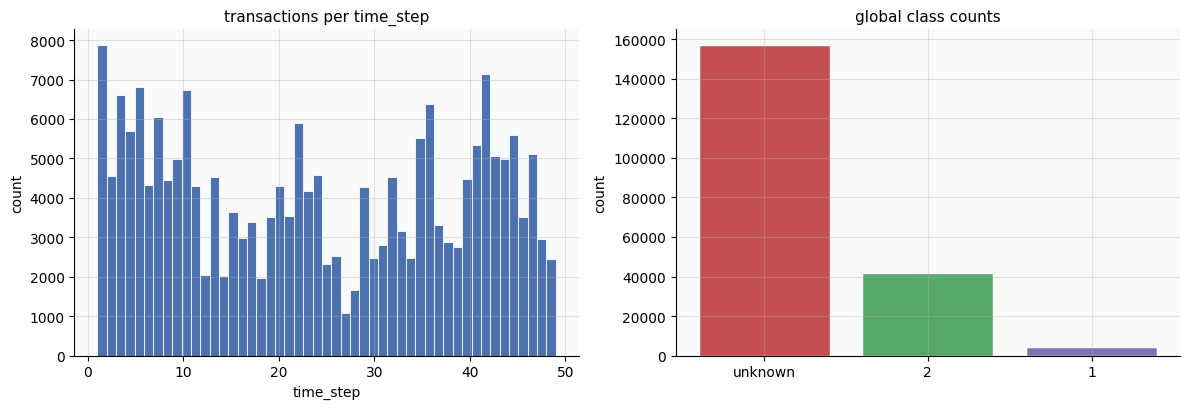

illicit share (all rows): 0.0223
time steps with ≥1 illicit: 49


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(df["time_step"], bins=49, color="#4c72b0", edgecolor="white", linewidth=0.6)
axes[0].set_xlabel("time_step")
axes[0].set_ylabel("count")
axes[0].set_title("transactions per time_step")

vc = df["class_str"].value_counts()
colors = ["#c44e52", "#55a868", "#8172b3"]
axes[1].bar(range(len(vc)), vc.values, color=colors[: len(vc)], edgecolor="white")
axes[1].set_xticks(range(len(vc)))
axes[1].set_xticklabels(vc.index.astype(str), rotation=0)
axes[1].set_ylabel("count")
axes[1].set_title("global class counts")

plt.tight_layout()
plt.show()

ill = df["class_str"] == "1"
print("illicit share (all rows):", f"{ill.mean():.4f}")
print("time steps with ≥1 illicit:", int(df.loc[ill, "time_step"].nunique()))

### 7] time-based train / validation / test masks

unique `time_step` values are sorted; **~70% / 15% / 15%** of **steps** go to train / val / test. edit `TRAIN_FRAC` and `VAL_FRAC` here if needed.

In [6]:
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
time_steps_sorted = sorted(df["time_step"].unique())
n_ts = len(time_steps_sorted)
i_train = int(n_ts * TRAIN_FRAC)
i_val = int(n_ts * (TRAIN_FRAC + VAL_FRAC))
train_steps = set(time_steps_sorted[:i_train])
val_steps = set(time_steps_sorted[i_train:i_val])
test_steps = set(time_steps_sorted[i_val:])

train_mask = df["time_step"].isin(train_steps).values
val_mask = df["time_step"].isin(val_steps).values
test_mask = df["time_step"].isin(test_steps).values

print("train steps:", min(train_steps), "..", max(train_steps), "| n =", len(train_steps))
print("val steps:  ", min(val_steps), "..", max(val_steps), "| n =", len(val_steps))
print("test steps: ", min(test_steps), "..", max(test_steps), "| n =", len(test_steps))

ill_m = df["class_str"].values == "1"
print(
    "illicit counts (train / val / test):",
    int((train_mask & ill_m).sum()),
    int((val_mask & ill_m).sum()),
    int((test_mask & ill_m).sum()),
)

train steps: 1 .. 34 | n = 34
val steps:   35 .. 41 | n = 7
test steps:  42 .. 49 | n = 8
illicit counts (train / val / test): 3462 675 408


### 8] integer node ids and feature matrix `X`

`df` is already sorted by `txId`. **`id2idx`** maps raw id → row index **0 … N−1** for graph libraries.

In [7]:
id2idx = {int(tx): i for i, tx in enumerate(df["txId"].values)}
idx2id = df["txId"].astype(int).tolist()
feature_names = [f"f_{i}" for i in range(165)]
X = df[feature_names].values.astype(np.float32)
N = len(df)
print("N nodes:", N)
print("X shape:", X.shape)

N nodes: 203769
X shape: (203769, 165)


### 9] build `edge_index` (endpoints in graph)

keep edges whose **both** endpoints exist in `id2idx`. shape **`(2, E)`**, `int64` — usual format for PyTorch Geometric.

uses **vectorized pandas `.map()`** instead of a Python loop for speed (~234k edges).

**note:** using the **full** graph with a train mask can let message passing see **test** neighbors (transductive). notebook 02 documents train-induced subgraph training vs full-graph inference.

In [8]:
def build_edge_index(edges_df, id2idx):
    src = edges_df["txId1"].map(id2idx)
    dst = edges_df["txId2"].map(id2idx)
    valid = src.notna() & dst.notna()
    skipped = int((~valid).sum())
    edge_index = np.array(
        [src[valid].astype(np.int64).values, dst[valid].astype(np.int64).values],
        dtype=np.int64,
    )
    return edge_index, skipped


edge_index, skipped = build_edge_index(edges, id2idx)
print("edge_index shape:", edge_index.shape, "| skipped edges:", skipped)

edge_index shape: (2, 234355) | skipped edges: 0


### 10] save preparation bundle for notebook 02

In [9]:
bundle = {
    "df_columns_meta": {
        "feature_names": feature_names,
        "train_steps_sample": (min(train_steps), max(train_steps)),
        "val_steps_sample": (min(val_steps), max(val_steps)),
        "test_steps_sample": (min(test_steps), max(test_steps)),
        "TRAIN_FRAC": TRAIN_FRAC,
        "VAL_FRAC": VAL_FRAC,
    },
    "X": X,
    "edge_index": edge_index,
    "train_mask": train_mask,
    "val_mask": val_mask,
    "test_mask": test_mask,
    "class_str": df["class_str"].values,
    "time_step": df["time_step"].values,
    "txId": df["txId"].values.astype(np.int64),
    "id2idx": id2idx,
    "idx2id": idx2id,
}

out_path = ARTIFACTS / "prep_bundle.pkl"
with open(out_path, "wb") as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
print("saved:", out_path.resolve())

saved: F:\msc ds\semester 2\UML\uml project\elliptic_bitcoin_project\artifacts\prep_bundle.pkl


### 11] next step

open **`02_unsupervised_detection_and_evaluation.ipynb`**, load `prep_bundle.pkl`, then fit unsupervised detectors and report **AUROC** / **AUPRC** on val and test for rows with `class_str` in `{"1","2"}` only.

***